In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow import keras
from tensorflow.keras import layers

In [14]:
df = pd.read_csv("sign_mnist_train.csv")

print(df.shape)
df.head()

(27455, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [15]:
X = df.drop("label", axis=1)
y = df["label"]

In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27455, 784)
y shape: (27455,)


In [17]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

n_classes = len(np.unique(y))

print("Number of classes:", n_classes)
print("Classes:", np.unique(y))

Number of classes: 24
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [18]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [19]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [20]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Shape after removing missing values: (27455, 785)
Missing values: 0


In [21]:
X = X.values.reshape(-1, 28, 28, 1)

print("Reshaped X:", X.shape)

Reshaped X: (27455, 28, 28, 1)


In [22]:
X = X.astype("float32") / 255.0

print("Minimum pixel:", X.min())
print("Maximum pixel:", X.max())

Minimum pixel: 0.0
Maximum pixel: 1.0


In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (21964, 28, 28, 1)
X_test: (5491, 28, 28, 1)


In [24]:
model = keras.Sequential([

    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(n_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,840 (479.84 KB)

 Trainable params: 122,840 (479.84 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6000 - loss: 1.3555 - val_accuracy: 0.8841 - val_loss: 0.3767
Epoch 2/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9459 - loss: 0.2045 - val_accuracy: 0.9775 - val_loss: 0.1055
Epoch 3/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.9907 - loss: 0.0545 - val_accuracy: 0.9968 - val_loss: 0.0268
Epoch 4/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9976 - loss: 0.0191 - val_accuracy: 0.9995 - val_loss: 0.0097
Epoch 5/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0034


In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9998 - loss: 0.0037
Test Loss: 0.0036765835247933865
Test Accuracy: 99.98%


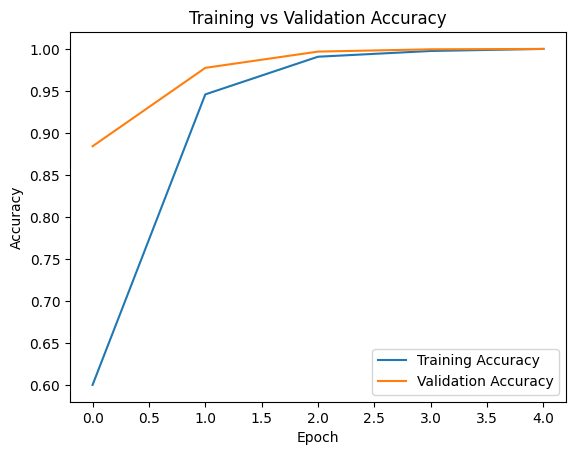

In [28]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


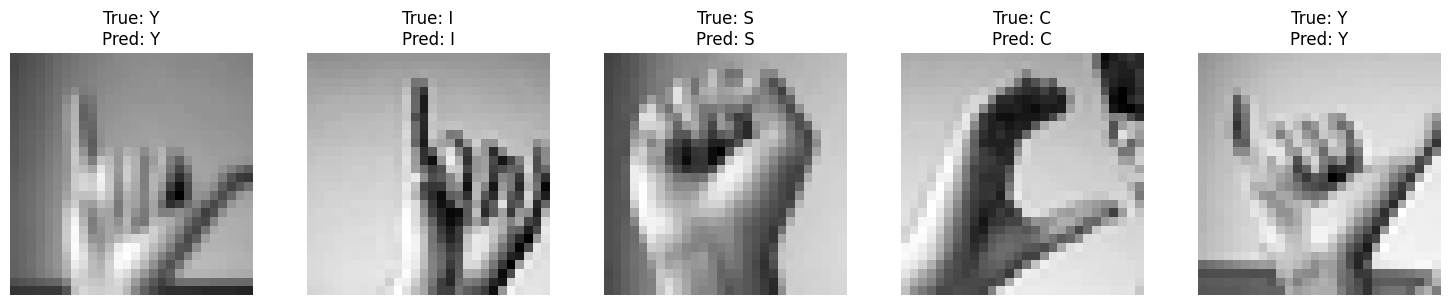

In [29]:
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

true_labels = encoder.inverse_transform(y_test)
pred_labels = encoder.inverse_transform(y_pred)

true_letters = [chr(65 + int(x)) for x in true_labels]
pred_letters = [chr(65 + int(x)) for x in pred_labels]

plt.figure(figsize=(15, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"True: {true_letters[i]}\n"
        f"Pred: {pred_letters[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()